# 07 — 252-day matrix spectrum & Marchenko–Pastur (Week 4, step 1)

**Objective.** See the actual spectrum before freezing the `rmt/` module: (1) 252-day correlation
matrices on devolatilised residuals (EWMA λ=0.94), (2) empirical spectrum vs MP density, (3) naïve
edge $(1+\sqrt{q_{mp}})^2$ vs **effective Laloux edge** $(1-\lambda_1/N)(1+\sqrt{q_{mp}})^2$ and
count K of "signal" eigenvalues, (4) iid test (the pipeline must find nothing in noise),
(5) clipping preview: $\bar\rho$ raw vs cleaned at the 116 rebalancings.

Decisions recorded (README §8bis): `q_mp` = N/T ; EWMA λ=0.94 ; daily eventually (here:
rebalancings for exploration) ; Laloux = piece of the pipeline (sets the clipping edge).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
P = ROOT / "data" / "processed"

ret_long = pd.read_parquet(P / "returns.parquet")
weights = pd.read_parquet(P / "weights.parquet")
ret_long["date"] = pd.to_datetime(ret_long["date"])
weights["rebalance_date"] = pd.to_datetime(weights["rebalance_date"])
weights["weight"] = weights["weight"].astype("float64")

# float64 everywhere (nullable dtypes break numpy — recurring lesson of the project)
ret = ret_long.pivot(index="date", columns="permno", values="ret").sort_index().astype("float64")
logret = np.log1p(ret)
# devolatilisation: PREDICTABLE EWMA(lambda=0.94) sigma (shift 1 day — no intra-window look-ahead)
sigma_ewma = logret.ewm(alpha=1 - 0.94, min_periods=20).std().shift(1)
z = logret / sigma_ewma
print(f"panel z: {z.shape} | permnos {z.shape[1]} | {z.index[0].date()} -> {z.index[-1].date()}")

panel z: (7552, 329) | permnos 329 | 1995-01-03 -> 2024-12-31


In [2]:
T_WIN, MIN_OBS = 252, 200

def corr_252(d, permnos):
    """252-day correlation of devolatilised residuals, complete-case, at date d."""
    win = z.loc[:d, [p for p in permnos if p in z.columns]].tail(T_WIN)
    win = win.dropna(axis=1, thresh=MIN_OBS).dropna(axis=0)
    C = win.corr().values
    return C, win.shape[1], win.shape[0]

def mp_density(lam, q_mp, s2=1.0):
    lo, hi = s2 * (1 - np.sqrt(q_mp))**2, s2 * (1 + np.sqrt(q_mp))**2
    out = np.zeros_like(lam)
    m = (lam > lo) & (lam < hi)
    out[m] = np.sqrt((hi - lam[m]) * (lam[m] - lo)) / (2 * np.pi * q_mp * s2 * lam[m])
    return out

def spectrum_stats(C, N, T):
    ev = np.linalg.eigvalsh(C)[::-1]
    q_mp = N / T
    lam1_share = ev[0] / N
    edge_naive = (1 + np.sqrt(q_mp))**2
    edge_laloux = (1 - lam1_share) * edge_naive
    return ev, q_mp, lam1_share, edge_naive, edge_laloux

In [3]:
# Loop over the 116 rebalancings: K counts and variance shares
rows = []
for reb, wq in weights.groupby("rebalance_date"):
    C, N, T = corr_252(reb, wq["permno"].tolist())
    if N < 60:
        continue
    ev, q_mp, l1s, e_n, e_l = spectrum_stats(C, N, T)
    rows.append((reb, N, T, q_mp, ev[0], l1s, (ev > e_n).sum(), (ev > e_l).sum()))
spec = pd.DataFrame(rows, columns=["rebalance_date", "N_eff", "T_eff", "q_mp",
                                    "lam1", "lam1_share", "K_naif", "K_laloux"]).set_index("rebalance_date")
print(f"rebalancings processed: {len(spec)} | median N_eff {spec['N_eff'].median():.0f} | median q_mp {spec['q_mp'].median():.3f}")
print(f"market-mode share λ1/N: median {spec['lam1_share'].median():.1%} | min {spec['lam1_share'].min():.1%} | max {spec['lam1_share'].max():.1%} ({spec['lam1_share'].idxmax().date()})")
print(f"K (\"signal\" eigenvalues) — NAÏVE edge: median {spec['K_naif'].median():.0f} | LALOUX edge: median {spec['K_laloux'].median():.0f}")
spec[["N_eff", "q_mp", "lam1_share", "K_naif", "K_laloux"]].describe().round(3)

rebalancings processed: 116 | median N_eff 100 | median q_mp 0.397
market-mode share λ1/N: median 33.5% | min 17.0% | max 54.4% (2012-06-29)
K ("signal" eigenvalues) — NAÏVE edge: median 4 | LALOUX edge: median 7


,N_eff,q_mp,lam1_share,K_naif,K_laloux
count,116.000,116.000,116.000,116.000,116.000
mean,99.621,0.400,0.335,3.828,7.181
std,0.505,0.018,0.090,1.090,0.974
min,98.000,0.389,0.170,2.000,5.000
25%,99.000,0.393,0.268,3.000,6.750
50%,100.000,0.397,0.335,4.000,7.000
75%,100.000,0.397,0.402,5.000,8.000
max,100.000,0.495,0.544,6.000,10.000


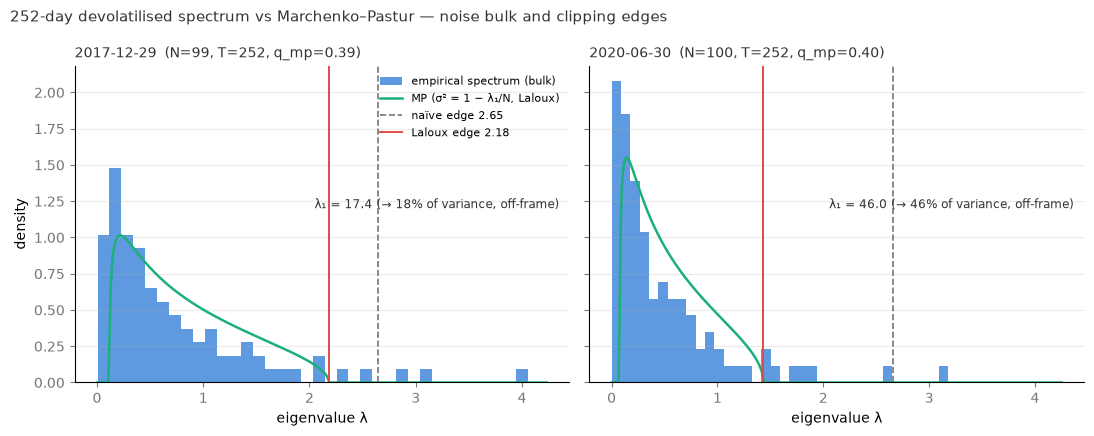

In [4]:
import matplotlib.pyplot as plt

C_BAR, C_MP, INK, MUTED, C_EDGE = "#2a78d6", "#1baf7a", "#333333", "#767676", "#e34948"
dates_fig = [pd.Timestamp("2017-12-29"), pd.Timestamp("2020-06-30")]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)

for ax, d in zip(axes, dates_fig):
    wq = weights[weights["rebalance_date"] == d]
    C, N, T = corr_252(d, wq["permno"].tolist())
    ev, q_mp, l1s, e_n, e_l = spectrum_stats(C, N, T)
    bulk = ev[ev < e_n * 1.6]
    ax.hist(bulk, bins=36, density=True, color=C_BAR, alpha=0.75,
            label="empirical spectrum (bulk)")
    lam = np.linspace(1e-3, e_n * 1.6, 400)
    ax.plot(lam, mp_density(lam, q_mp, s2=1 - l1s), color=C_MP, lw=1.8,
            label="MP (σ² = 1 − λ₁/N, Laloux)")
    ax.axvline(e_n, color=MUTED, ls="--", lw=1.2, label=f"naïve edge {e_n:.2f}")
    ax.axvline(e_l, color=C_EDGE, ls="-", lw=1.4, label=f"Laloux edge {e_l:.2f}")
    ax.annotate(f"λ₁ = {ev[0]:.1f} (→ {l1s:.0%} of variance, off-frame)",
                xy=(0.98, 0.55), xycoords="axes fraction", ha="right", fontsize=8.5, color=INK)
    ax.set_title(f"{d.date()}  (N={N}, T={T}, q_mp={q_mp:.2f})", loc="left", fontsize=10, color=INK)
    ax.set_xlabel("eigenvalue λ")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(colors=MUTED)
axes[0].set_ylabel("density")
axes[0].legend(loc="upper right", frameon=False, fontsize=8)
fig.suptitle("252-day devolatilised spectrum vs Marchenko–Pastur — noise bulk and clipping edges",
             x=0.01, ha="left", fontsize=11, color=INK)
fig.tight_layout()
fig.savefig(ROOT / "results" / "figures" / "fig_mp_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
# iid test: the pipeline must find NOTHING in pure noise
rng = np.random.default_rng(7)
X = rng.standard_normal((252, 100))
C_iid = np.corrcoef(X, rowvar=False)
ev_iid = np.linalg.eigvalsh(C_iid)[::-1]
q_mp = 100 / 252
e_n = (1 + np.sqrt(q_mp))**2
print(f"iid N(0,1) 252x100: λ_max = {ev_iid[0]:.3f} vs MP edge {e_n:.3f} | K(>edge) = {(ev_iid > e_n).sum()}")
print(f"λ_min = {ev_iid[-1]:.3f} vs lower edge {(1 - np.sqrt(q_mp))**2:.3f} | trace/N = {ev_iid.mean():.4f}")

iid N(0,1) 252x100: λ_max = 2.585 vs MP edge 2.657 | K(>edge) = 0
λ_min = 0.140 vs lower edge 0.137 | trace/N = 1.0000


In [6]:
# Clipping preview: effect on rho_bar (weighted option B) at the 116 rebalancings
def clip_laloux(C):
    N = C.shape[0]
    ev, V = np.linalg.eigh(C)          # ascending
    q_mp = N / T_WIN
    edge = (1 - ev[-1] / N) * (1 + np.sqrt(q_mp))**2
    bulk = ev < edge
    ev2 = ev.copy()
    if bulk.any():
        ev2[bulk] = ev[bulk].mean()    # trace preserved over the bulk
    C2 = (V * ev2) @ V.T
    d = np.sqrt(np.diag(C2))
    C2 = C2 / np.outer(d, d)           # renormalisation diag = 1
    return C2

def rho_bar_w(C, w_vec, sig_vec):
    v = np.asarray(w_vec, dtype=float) * np.asarray(sig_vec, dtype=float)
    num = v @ C @ v - (v**2).sum()
    den = v.sum()**2 - (v**2).sum()
    return num / den

sig252 = logret.rolling(252, min_periods=200).std() * np.sqrt(252)
pairs = []
for reb, wq in weights.groupby("rebalance_date"):
    permnos = wq["permno"].tolist()
    win = z.loc[:reb, [p for p in permnos if p in z.columns]].tail(T_WIN)
    win = win.dropna(axis=1, thresh=MIN_OBS).dropna(axis=0)
    if win.shape[1] < 60:
        continue
    C = win.corr().to_numpy(dtype="float64")
    kept = win.columns
    wmap = wq.set_index("permno")["weight"].reindex(kept)
    smap = sig252.loc[:reb, kept].iloc[-1]
    ok = (wmap.notna() & smap.notna()).to_numpy()
    wv = wmap.to_numpy(dtype="float64")[ok]
    sv = smap.to_numpy(dtype="float64")[ok]
    Cok = C[np.ix_(ok, ok)]
    pairs.append((reb, rho_bar_w(Cok, wv / wv.sum(), sv),
                  rho_bar_w(clip_laloux(Cok), wv / wv.sum(), sv)))
cmp_ = pd.DataFrame(pairs, columns=["rebalance_date", "rho_raw", "rho_clean"]).set_index("rebalance_date")
diff = cmp_["rho_clean"] - cmp_["rho_raw"]
print(f"rho_bar 252d raw vs cleaned ({len(cmp_)} rebal.):")
print(f"  correlation of the two series: {cmp_['rho_raw'].corr(cmp_['rho_clean']):.4f}")
print(f"  diff (clean − raw): mean {diff.mean():+.4f} | median abs {diff.abs().median():.4f} | max abs {diff.abs().max():.4f} ({diff.abs().idxmax().date()})")
cmp_.describe().round(4)

rho_bar 252d raw vs cleaned (116 rebal.):
  correlation of the two series: 0.9983
  diff (clean − raw): mean -0.0111 | median abs 0.0109 | max abs 0.0239 (2023-03-31)


,rho_raw,rho_clean
count,116.0000,116.0000
mean,0.3337,0.3225
std,0.0939,0.0919
min,0.1502,0.1441
25%,0.2616,0.2531
50%,0.3273,0.3210
75%,0.4166,0.4006
max,0.5350,0.5268


## Findings (to check against the outputs)

1. The empirical bulk should match the MP density **with σ² = 1−λ₁/N** (Laloux) — not with σ²=1:
   this is the visual proof that the correction is needed.
2. K (Laloux edge) expected ~5–10: market + sectors. The naïve edge, ~35% too high, misses some.
3. iid: K = 0 expected (the pipeline invents no signal).
4. ρ̄ raw vs cleaned: expected difference **small** (clipping preserves the market mode which
   dominates ρ̄) — this is the argument for focusing the RMT effort on the **features** and the
   parsimonious leg, not just the scalar (expectation set from the S4 briefing).

**→ Validation of these findings → promotion into `src/dispersion/rmt/` (step 2).**